In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_DIR = Path("data")
ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLS = ["Tg", "FFV", "Tc", "Density", "Rg"]

## CT1.1 Load and inspect the main files

In [2]:
def load_main_tables(data_dir):
    """Load train/test/sample_submission tables and return them in a dict."""
    base = Path(data_dir)
    tables = {
        "train": pd.read_csv(base / "train.csv"),
        "test": pd.read_csv(base / "test.csv"),
        "sample_submission": pd.read_csv(base / "sample_submission.csv"),
    }
    return tables

In [6]:
tables = load_main_tables(DATA_DIR)

for name, df in tables.items():
    print(f"\n=== {name} ===")
    print(f"shape: {df.shape}")
    print("columns:", list(df.columns))
    display(df.head())


=== train ===
shape: (7973, 7)
columns: ['id', 'SMILES', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']


,id,SMILES,Tg,FFV,Tc,Density,Rg
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,NaN,0.374645,0.205667,NaN,NaN
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,NaN,0.370410,NaN,NaN,NaN
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,NaN,0.378860,NaN,NaN,NaN
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,NaN,0.387324,NaN,NaN,NaN
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,NaN,0.355470,NaN,NaN,NaN



=== test ===
shape: (3, 2)
columns: ['id', 'SMILES']


,id,SMILES
0,1109053969,*Oc1ccc(C=NN=Cc2ccc(Oc3ccc(C(c4ccc(*)cc4)(C(F)...
1,1422188626,*Oc1ccc(C(C)(C)c2ccc(Oc3ccc(C(=O)c4cccc(C(=O)c...
2,2032016830,*c1cccc(OCCCCCCCCOc2cccc(N3C(=O)c4ccc(-c5cccc6...



=== sample_submission ===
shape: (3, 6)
columns: ['id', 'Tg', 'FFV', 'Tc', 'Density', 'Rg']


,id,Tg,FFV,Tc,Density,Rg
0,1109053969,0,0,0,0,0
1,1422188626,0,0,0,0,0
2,2032016830,0,0,0,0,0


## CT1.2 Missing values and availability plot

In [8]:
def missing_value_report(train_df):
    """Return a report with columns: target, total, missing, available."""
    total = len(train_df)
    rows = []
    for col in TARGET_COLS:
        missing = train_df[col].isna().sum()
        rows.append({"target": col, "total": total, "missing": missing, "available": total - missing})
    return pd.DataFrame(rows)

,target,total,missing,available
0,Tg,7973,7462,511
1,FFV,7973,943,7030
2,Tc,7973,7236,737
3,Density,7973,7360,613
4,Rg,7973,7359,614


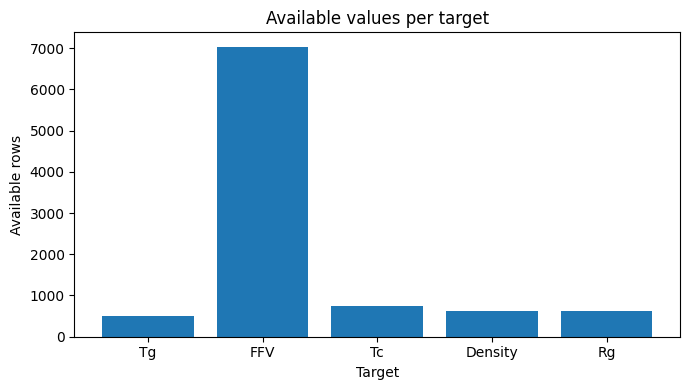

In [9]:
train_df = tables["train"]
report = missing_value_report(train_df)
display(report)

plt.figure(figsize=(7, 4))
plt.bar(report["target"], report["available"])
plt.title("Available values per target")
plt.xlabel("Target")
plt.ylabel("Available rows")
plt.tight_layout()
plt.show()

## CT1.3 Build one clean FFV table

In [3]:
def build_ffv_clean(train_df):
    """Return a clean FFV dataframe with columns id, SMILES, FFV."""
    ffv_df = train_df.loc[train_df["FFV"].notna(), ["id", "SMILES", "FFV"]].copy()
    return ffv_df

In [10]:
ffv_clean = build_ffv_clean(train_df)
display(ffv_clean.head())
print("ffv_clean shape:", ffv_clean.shape)

ffv_clean_path = ARTIFACT_DIR / "ffv_clean.csv"
ffv_clean.to_csv(ffv_clean_path, index=False)
print("Saved:", ffv_clean_path)

,id,SMILES,FFV
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470


ffv_clean shape: (7030, 3)
Saved: artifacts/ffv_clean.csv


## CT1.4 Add basic SMILES features

In [4]:
def add_basic_smiles_features(ffv_df):
    """Add simple string-count features to FFV dataframe."""
    out = ffv_df.copy()
    smiles = out["SMILES"].fillna("")

    out["smiles_len"] = smiles.str.len()
    out["count_star"] = smiles.str.count(r"\*")
    out["count_C"] = smiles.str.count("C")
    out["count_O"] = smiles.str.count("O")
    out["count_N"] = smiles.str.count("N")
    out["count_equal"] = smiles.str.count("=")

    return out

In [11]:
ffv_features = add_basic_smiles_features(ffv_clean)
display(ffv_features.head())

ffv_features_path = ARTIFACT_DIR / "ffv_features_basic.csv"
ffv_features.to_csv(ffv_features_path, index=False)
print("Saved:", ffv_features_path)

,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645,26,2,9,2,0,1
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410,82,2,19,0,2,0
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860,134,2,14,9,0,7
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324,79,2,4,0,2,0
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470,118,2,30,12,4,4


Saved: artifacts/ffv_features_basic.csv


## CT1.5 Fixed train/validation split

In [5]:
def make_split(df, valid_size=0.2, seed=42):
    """Return dataframe with a reproducible split column: train/valid."""
    out = df.copy()
    rng = np.random.default_rng(seed)

    valid_n = int(np.floor(len(out) * valid_size))
    valid_idx = rng.choice(out.index.to_numpy(), size=valid_n, replace=False)

    out["split"] = "train"
    out.loc[valid_idx, "split"] = "valid"
    return out

In [12]:
ffv_ready_split = make_split(ffv_features, valid_size=0.2, seed=42)
display(ffv_ready_split.head())
print(ffv_ready_split["split"].value_counts())

ffv_ready_split_path = ARTIFACT_DIR / "ffv_ready_split.csv"
ffv_ready_split.to_csv(ffv_ready_split_path, index=False)
print("Saved:", ffv_ready_split_path)

,id,SMILES,FFV,smiles_len,count_star,count_C,count_O,count_N,count_equal,split
0,87817,*CC(*)c1ccccc1C(=O)OCCCCCC,0.374645,26,2,9,2,0,1,train
1,106919,*Nc1ccc([C@H](CCC)c2ccc(C3(c4ccc([C@@H](CCC)c5...,0.370410,82,2,19,0,2,0,train
2,388772,*Oc1ccc(S(=O)(=O)c2ccc(Oc3ccc(C4(c5ccc(Oc6ccc(...,0.378860,134,2,14,9,0,7,train
3,519416,*Nc1ccc(-c2c(-c3ccc(C)cc3)c(-c3ccc(C)cc3)c(N*)...,0.387324,79,2,4,0,2,0,train
4,539187,*Oc1ccc(OC(=O)c2cc(OCCCCCCCCCOCC3CCCN3c3ccc([N...,0.355470,118,2,30,12,4,4,train


split
train    5624
valid    1406
Name: count, dtype: int64
Saved: artifacts/ffv_ready_split.csv


## CT1.6 Short written interpretation

The target with the most available rows is **FFV** (it has the highest availability in the report).
FFV is a good first target because it has many labels, so we can train and validate models more reliably with less risk of overfitting to tiny samples.
It is also central for polymer free-volume behavior, so it is meaningful both scientifically and practically.
A useful basic SMILES feature is `smiles_len`, because molecule size/complexity often correlates with physical properties and can provide a strong baseline signal.

## Optional bonus: RDKit descriptors

In [13]:
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors

    def _rdkit_descriptors(smiles: str):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.nan, np.nan, np.nan
        return (
            Descriptors.MolWt(mol),
            Descriptors.NumValenceElectrons(mol),
            Descriptors.TPSA(mol),
        )

    rdkit_df = ffv_ready_split.copy()
    rdkit_values = rdkit_df["SMILES"].fillna("").apply(_rdkit_descriptors)
    rdkit_df[["MolWt", "NumValenceElectrons", "TPSA"]] = pd.DataFrame(
        rdkit_values.tolist(), index=rdkit_df.index
    )

    rdkit_path = ARTIFACT_DIR / "ffv_features_rdkit.csv"
    rdkit_df.to_csv(rdkit_path, index=False)
    print("Saved:", rdkit_path)
except ImportError:
    print("RDKit not installed. Skip bonus section.")

Saved: artifacts/ffv_features_rdkit.csv


## Required checks

In [18]:
assert "train" in tables, "Missing 'train' in tables dict"
assert len(tables["train"]) == 7973, "train.csv should have 7973 rows"

assert ffv_clean.shape[0] == 7030, "FFV non-missing rows should be 7030"
assert list(ffv_clean.columns) == ["id", "SMILES", "FFV"], "ffv_clean columns must be id, SMILES, FFV"

feature_cols = ["smiles_len", "count_star", "count_C", "count_O", "count_N", "count_equal"]
for col in feature_cols:
    assert col in ffv_features.columns, f"Missing feature column: {col}"
    assert pd.api.types.is_numeric_dtype(ffv_features[col]), f"Feature column {col} must be numeric"

assert "split" in ffv_ready_split.columns, "Missing split column"
assert set(ffv_ready_split["split"].unique()) <= {"train", "valid"}, "split must contain only train/valid"
recheck = make_split(ffv_features, valid_size=0.2, seed=42)
assert recheck["split"].equals(ffv_ready_split["split"]), "Split is not reproducible with seed=42"

required_files = [
    ARTIFACT_DIR / "ffv_clean.csv",
    ARTIFACT_DIR / "ffv_features_basic.csv",
    ARTIFACT_DIR / "ffv_ready_split.csv",
]
for path in required_files:
    assert path.exists(), f"Missing output file: {path}"
    tmp_df = pd.read_csv(path)
    assert len(tmp_df) > 0, f"Output file is empty: {path}"

print("All required checks passed.")

All required checks passed.
